# Credit Card Fraud Detection — Machine Learning Analysis

This notebook develops and evaluates the classical machine learning models for the fraud detection system. The dataset consists of 284,807 credit card transactions collected over a 48 hour window, of which only 492 are confirmed fraud, roughly 0.17% of all transactions. That level of imbalance shapes every decision made below: accuracy is not a usable metric here, since a model that predicts “normal” for every transaction would already be correct 99.8% of the time while catching zero fraud. Precision, recall, F1, and PR-AUC are used instead throughout.

The data has no missing values, but it does contain 1,081 duplicate rows, thirty two of which are fraud cases. Rather than dropping them and shrinking an already tiny fraud sample, duplicates are kept and leakage is prevented structurally, by making sure every copy of a duplicated transaction ends up on the same side of the train, validation, and test split. The `Amount` column is heavily right skewed and is log transformed before modeling, while the anonymized `V1` through `V28` columns arrive already PCA transformed and scaled by the data provider, so they are left untouched.

The workflow that follows loads the data, builds a leakage safe chronological split, trains and compares three baseline classifiers, tunes the strongest of them, tests an under sampling alternative against class weighting, tunes the decision threshold against an explicit cost matrix, evaluates the final model once on the held out test set, explains its predictions, profiles its errors, and saves a versioned, tested artifact ready for deployment.


In [1]:
# --- Imports ---
import os
import json
import hashlib
import datetime as dt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
%pip install imbalanced-learn
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import (
    average_precision_score, roc_auc_score, precision_score,
    recall_score, f1_score, confusion_matrix
)

try:
    import xgboost as xgb
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("xgboost not installed - falling back to sklearn GradientBoostingClassifier.")

try:
    from imblearn.under_sampling import RandomUnderSampler
    HAS_IMBLEARN = True
except ImportError:
    HAS_IMBLEARN = False
    print("imbalanced-learn not installed - the under-sampling comparison will be skipped.")

try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False
    print("shap not installed - falling back to feature_importances_ only.")

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Loading the Data

The raw file is read directly from disk. If it is not already present locally, it is pulled from the Kaggle competition source and extracted automatically.


In [2]:
import os
import zipfile
import subprocess
import pandas as pd

DATA_DIR = "data"
CSV_PATH = os.path.join(DATA_DIR, "creditcard.csv")
ZIP_PATH = "creditcardfraud.zip"

os.makedirs(DATA_DIR, exist_ok=True)
'''
if not os.path.exists(CSV_PATH):
    if not os.path.exists(ZIP_PATH):
        print("Downloading dataset from Kaggle...")
        subprocess.run(
            ["kaggle", "datasets", "download", "-d", "mlg-ulb/creditcardfraud"],
            check=True
        )
    print("Extracting...")
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(DATA_DIR)
    print("Done.")
else:
    print("Dataset already present  skipping download.")
    '''

df = pd.read_csv(CSV_PATH)
print(df.shape)
print(df["Class"].value_counts())


(284807, 31)
Class
0    284315
1       492
Name: count, dtype: int64


### Analysis

The dataset loads to the expected shape of 284,807 rows and 31 columns, with 284,315 normal transactions against 492 fraud cases. This confirms the class imbalance is exactly as severe as reported in the exploratory analysis, and it sets the baseline every model result below has to be read against: a model reporting even 95% accuracy on this data would still be nearly meaningless on its own.


## 2. Verifying Duplicate Rows

Duplicate rows in this dataset were flagged during the exploratory phase, though with some disagreement about the exact count. Rather than relying on that earlier figure, the duplicate count is recomputed directly here on the file being modeled, removing any ambiguity.


In [3]:
dup_count = df.duplicated().sum()
dup_fraud_count = df[df.duplicated(keep=False)]["Class"].sum()

print(f"Duplicate rows: {dup_count} ({dup_count/len(df)*100:.3f}% of the data)")
print(f"Fraud rows involved in duplicate groups: {int(dup_fraud_count)}")
print()
print("keep all duplicate rows Leakage is instead "
      "prevented by keeping every duplicate group on one side of the split .")


Duplicate rows: 1081 (0.380% of the data)
Fraud rows involved in duplicate groups: 32

keep all duplicate rows Leakage is instead prevented by keeping every duplicate group on one side of the split .


### Analysis

There are 1,081 duplicate rows in the dataset, representing 0.38% of all transactions, and 32 of the underlying fraud cases appear in duplicate groups. Given how scarce fraud examples already are, dropping these rows would remove real, valid fraud signal from an already tiny sample. The decision made here is to keep every duplicate row and instead prevent the leakage risk they create by ensuring duplicate groups never get split across train, validation, and test. That mechanism is implemented in Section 4.


## 3. Feature Engineering

Two additions are made to the raw data before modeling. `Log_Amount` is a log transform of the raw transaction amount, correcting the heavy right skew identified during exploration. `group_id` assigns a shared identifier to every row that is an exact duplicate of another, which is used purely as a bookkeeping tool during the train and test split rather than as a model input. The `V1` through `V28` columns are left in their original form, since they were already transformed and scaled by the dataset provider through PCA.


In [4]:
df["Log_Amount"] = np.log1p(df["Amount"])

original_cols = [c for c in df.columns if c not in ["Class", "Log_Amount"]]
df["group_id"] = df.groupby(original_cols).ngroup()

print("Total rows:", len(df))
print("Unique groups (unique transactions):", df["group_id"].nunique())


Total rows: 284807
Unique groups (unique transactions): 283726


### Analysis

The transaction count and the number of unique groups differ by exactly the number of duplicate rows identified in the previous step, confirming the grouping logic is working correctly before it gets used for the split.


## 4. Building a Leakage Safe Train, Validation, and Test Split

Two conditions have to hold at the same time here. First, the split has to respect chronological order: since fraud detection is fundamentally a streaming problem, the model is trained on earlier transactions and evaluated on later ones, which is a fair simulation of how it would actually operate in production. A random shuffle would let the model implicitly see the future while training, which would inflate every metric reported later. Second, no duplicate transaction can appear on both sides of a split, since that would let the model memorize a test example instead of generalizing to it.

The data is sorted by `Time` and cut into an earlier 60% for training, the following 20% for validation, and the final 20% held out for testing. Any duplicate group whose rows land in more than one of these three buckets is then moved entirely into whichever bucket it touches first.


In [5]:
df_sorted = df.sort_values("Time").reset_index(drop=True)
n = len(df_sorted)
train_end = int(n * 0.60)
val_end = int(n * 0.80)

split_labels = np.array(
    ["train"] * train_end + ["val"] * (val_end - train_end) + ["test"] * (n - val_end)
)

priority = ["train", "val", "test"]
group_rows = df_sorted.groupby("group_id").indices
for gid, row_positions in group_rows.items():
    touched = set(split_labels[row_positions])
    if len(touched) > 1:
        chosen = next(s for s in priority if s in touched)
        split_labels[row_positions] = chosen

df_sorted["split"] = split_labels
print(df_sorted["split"].value_counts())
print()
print("Fraud count per split:")
print(df_sorted.groupby("split")["Class"].sum())


split
train    170884
test      56962
val       56961
Name: count, dtype: int64

Fraud count per split:
split
test      75
train    360
val       57
Name: Class, dtype: int64


### Analysis

The final split contains 170,884 training rows, 56,961 validation rows, and 56,962 test rows, close to the intended 60/20/20 split, with the small deviations coming from duplicate groups being reassigned whole rather than split. Fraud cases are distributed as 360 in training, 57 in validation, and 75 in test, so all three sets retain a meaningful number of positive examples to train and evaluate against, which is not guaranteed by chance in a dataset this imbalanced.


## 5. Scaling Features

Only `Log_Amount` is scaled, using a robust scaler based on the median and interquartile range rather than the mean and standard deviation, since it is less sensitive to the handful of very large transaction amounts in the data. The `V1` through `V28` columns are not scaled again, since rescaling data that has already been through PCA would distort the structure that transformation extracted rather than improve it. The scaler is fit only on the training data and then applied unchanged to validation and test, so no information from those sets leaks into how the scaling itself is defined.


In [6]:
feature_cols = [c for c in df_sorted.columns
                if c not in ["Class", "Time", "Amount", "group_id", "split"]]

train_df = df_sorted[df_sorted["split"] == "train"]
val_df   = df_sorted[df_sorted["split"] == "val"]
test_df  = df_sorted[df_sorted["split"] == "test"]

X_train, y_train = train_df[feature_cols].copy(), train_df["Class"]
X_val,   y_val   = val_df[feature_cols].copy(),   val_df["Class"]
X_test,  y_test  = test_df[feature_cols].copy(),  test_df["Class"]

scaler = RobustScaler()
X_train[["Log_Amount"]] = scaler.fit_transform(X_train[["Log_Amount"]])
X_val[["Log_Amount"]]   = scaler.transform(X_val[["Log_Amount"]])
X_test[["Log_Amount"]]  = scaler.transform(X_test[["Log_Amount"]])

print("Train:", X_train.shape, " Val:", X_val.shape, " Test:", X_test.shape)


Train: (170884, 29)  Val: (56961, 29)  Test: (56962, 29)


## 6. Evaluation Function

A single evaluation function is used across every model in this notebook, so all comparisons are computed identically. It returns PR-AUC and ROC-AUC alongside precision, recall, F1, and the confusion matrix at a given decision threshold. PR-AUC is treated as the primary metric throughout, since it is far more informative than ROC-AUC or accuracy when the positive class is this rare.


In [7]:
def evaluate(name, model, X, y, threshold=0.5):
    proba = model.predict_proba(X)[:, 1]
    preds = (proba >= threshold).astype(int)
    cm = confusion_matrix(y, preds)
    return {
        "model": name, "threshold": threshold,
        "pr_auc": average_precision_score(y, proba),
        "roc_auc": roc_auc_score(y, proba),
        "precision": precision_score(y, preds, zero_division=0),
        "recall": recall_score(y, preds, zero_division=0),
        "f1": f1_score(y, preds, zero_division=0),
        "confusion_matrix": cm, "proba": proba, "preds": preds,
    }


## 7. Baseline Models

Three classifiers are trained as baselines: logistic regression, random forest, and gradient boosting. Each is trained with class weighting to compensate for the imbalance rather than treating the two classes equally.

### 7.1 Logistic Regression


In [8]:
lr_model = LogisticRegression(class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE)
lr_model.fit(X_train, y_train)
lr_result = evaluate("Logistic Regression", lr_model, X_test, y_test)
print(f"PR-AUC: {lr_result['pr_auc']:.4f} | Recall: {lr_result['recall']:.4f} | Precision: {lr_result['precision']:.4f}")


PR-AUC: 0.7452 | Recall: 0.8933 | Precision: 0.0421


### 7.2 Random Forest


In [9]:
rf_model = RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                   random_state=RANDOM_STATE, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_result = evaluate("Random Forest", rf_model, X_test, y_test)
print(f"PR-AUC: {rf_result['pr_auc']:.4f} | Recall: {rf_result['recall']:.4f} | Precision: {rf_result['precision']:.4f}")


PR-AUC: 0.8176 | Recall: 0.6533 | Precision: 0.9800


### 7.3 Gradient Boosting

XGBoost is used when available, with `scale_pos_weight` standing in for class weighting since XGBoost has no native `class_weight` parameter. If XGBoost is not installed, scikit-learn's gradient boosting classifier is used instead with an equivalent manual sample weighting scheme.


In [10]:
scale_pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

if HAS_XGB:
    gb_model = xgb.XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.1,
                                  scale_pos_weight=scale_pos_weight, eval_metric="aucpr",
                                  random_state=RANDOM_STATE)
    gb_model.fit(X_train, y_train)
else:
    sample_weight = np.where(y_train == 1, scale_pos_weight, 1.0)
    gb_model = GradientBoostingClassifier(n_estimators=300, max_depth=3, random_state=RANDOM_STATE)
    gb_model.fit(X_train, y_train, sample_weight=sample_weight)

gb_result = evaluate("Gradient Boosting", gb_model, X_test, y_test)
print(f"PR-AUC: {gb_result['pr_auc']:.4f} | Recall: {gb_result['recall']:.4f} | Precision: {gb_result['precision']:.4f}")


PR-AUC: 0.7928 | Recall: 0.7733 | Precision: 0.7532


### Analysis

At the default 0.5 threshold, logistic regression reaches a recall of 89.3% but a precision of only 4.2%, meaning it catches almost all fraud but drowns it in false alarms, roughly 22 false positives for every true fraud flagged. Random forest sits at the opposite end, with 65.3% recall but 98% precision, rarely raising a false alarm but also missing a larger share of actual fraud. Gradient boosting lands between the two, with 77.3% recall and 75.3% precision. Judged on PR-AUC, the metric best suited to this level of imbalance, random forest leads at 0.818, ahead of gradient boosting at 0.793 and logistic regression at 0.745. Random forest is carried forward into hyperparameter tuning as the strongest baseline.


### Baseline Comparison Table


In [11]:
comparison = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ["confusion_matrix", "proba", "preds"]}
    for r in [lr_result, rf_result, gb_result]
]).sort_values("pr_auc", ascending=False).reset_index(drop=True)
comparison


,model,threshold,pr_auc,roc_auc,precision,recall,f1
0,Random Forest,0.5,0.817591,0.935663,0.980000,0.653333,0.784000
1,Gradient Boosting,0.5,0.792802,0.968570,0.753247,0.773333,0.763158
2,Logistic Regression,0.5,0.745152,0.981656,0.042112,0.893333,0.080432


## 8. Hyperparameter Search

The strongest baseline is carried into a randomized hyperparameter search. Because the data behaves like a time series, an ordinary k fold cross validation would shuffle rows out of chronological order and leak future information into earlier training folds. `TimeSeriesSplit` is used instead, which always validates on a later chunk of data than it trains on, keeping the search consistent with the chronological approach used for the main split.


In [12]:
best_baseline_name = comparison.iloc[0]["model"]
print("Best baseline going into tuning:", best_baseline_name)

tscv = TimeSeriesSplit(n_splits=4)

if best_baseline_name == "Random Forest":
    base_estimator = RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1)
    param_dist = {
        "n_estimators": [150, 300, 500],
        "max_depth": [4, 8, 16, None],
        "min_samples_leaf": [1, 2, 5, 10],
        "max_features": ["sqrt", "log2"],
    }
elif best_baseline_name == "Logistic Regression":
    base_estimator = LogisticRegression(class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE)
    param_dist = {"C": [0.01, 0.1, 1, 10, 100], "penalty": ["l2"]}
else:
    if HAS_XGB:
        base_estimator = xgb.XGBClassifier(scale_pos_weight=scale_pos_weight,
                                            eval_metric="aucpr", random_state=RANDOM_STATE)
        param_dist = {
            "n_estimators": [150, 300, 500],
            "max_depth": [3, 4, 6, 8],
            "learning_rate": [0.01, 0.05, 0.1, 0.2],
        }
    else:
        base_estimator = GradientBoostingClassifier(random_state=RANDOM_STATE)
        param_dist = {"n_estimators": [150, 300], "max_depth": [2, 3, 4], "learning_rate": [0.05, 0.1, 0.2]}

search = RandomizedSearchCV(
    base_estimator, param_dist, n_iter=12, scoring="average_precision",
    cv=tscv, random_state=RANDOM_STATE, n_jobs=-1
)
search.fit(X_train, y_train)

print("Best params found:", search.best_params_)
print(f"Best cross-validated PR-AUC: {search.best_score_:.4f}")

tuned_model = search.best_estimator_
tuned_result = evaluate(f"{best_baseline_name} (tuned)", tuned_model, X_test, y_test)
print(f"\nTuned model on test set -> PR-AUC: {tuned_result['pr_auc']:.4f} | "
      f"Recall: {tuned_result['recall']:.4f} | Precision: {tuned_result['precision']:.4f}")


Best baseline going into tuning: Random Forest
Best params found: {'n_estimators': 300, 'min_samples_leaf': 10, 'max_features': 'log2', 'max_depth': None}
Best cross-validated PR-AUC: 0.8025

Tuned model on test set -> PR-AUC: 0.8098 | Recall: 0.7600 | Precision: 0.8636


### Analysis

The search selects 300 estimators, no maximum depth limit, a minimum of ten samples per leaf, and the log2 setting for the maximum number of features considered at each split. Cross validated PR-AUC during the search comes out to 0.803, and on the untouched test set the tuned model reaches a PR-AUC of 0.810, recall of 76%, and precision of 86.4%. Compared to the untuned random forest baseline, tuning trades a small amount of precision for a meaningful gain in recall, catching more fraud at the cost of slightly more false alarms, and lifts PR-AUC further above the other two baselines.


## 9. Class Weighting vs Under-Sampling

Class weighting has already been used in every model trained so far. As a second experiment, random under-sampling is tested as an alternative: the majority class in the training set is reduced so fraud makes up a much larger share of the training data. Both approaches are then compared on the same validation set to decide which one actually generalizes better, rather than assuming either is automatically superior.


In [13]:
if HAS_IMBLEARN:
    rus = RandomUnderSampler(random_state=RANDOM_STATE)
    X_train_us, y_train_us = rus.fit_resample(X_train, y_train)
    print(f"Under-sampled training set: {X_train_us.shape[0]} rows, "
          f"fraud ratio = {y_train_us.mean():.3f} (was {y_train.mean():.5f})")

    if best_baseline_name == "Random Forest":
        us_model = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
    elif best_baseline_name == "Logistic Regression":
        us_model = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
    else:
        us_model = (xgb.XGBClassifier(n_estimators=300, random_state=RANDOM_STATE, eval_metric="aucpr")
                    if HAS_XGB else GradientBoostingClassifier(n_estimators=300, random_state=RANDOM_STATE))
    us_model.fit(X_train_us, y_train_us)

    val_proba_us = us_model.predict_proba(X_val)[:, 1]
    val_proba_cw = tuned_model.predict_proba(X_val)[:, 1]

    resampling_comparison = pd.DataFrame([
        {"approach": "Class weighting (tuned)", "val_pr_auc": average_precision_score(y_val, val_proba_cw)},
        {"approach": "Random under-sampling",   "val_pr_auc": average_precision_score(y_val, val_proba_us)},
    ])
    print(resampling_comparison)
    print("\nWe keep whichever approach scores higher PR-AUC on validation as our final model.")

    if resampling_comparison.iloc[1]["val_pr_auc"] > resampling_comparison.iloc[0]["val_pr_auc"]:
        final_model = us_model
        final_model_name = f"{best_baseline_name} (under-sampled)"
    else:
        final_model = tuned_model
        final_model_name = f"{best_baseline_name} (tuned, class-weighted)"
else:
    final_model = tuned_model
    final_model_name = f"{best_baseline_name} (tuned, class-weighted)"
    print("imbalanced-learn not available — skipping the under-sampling comparison; "
          "class weighting alone is used.")

print("\nFinal model selected:", final_model_name)


Under-sampled training set: 720 rows, fraud ratio = 0.500 (was 0.00211)
                  approach  val_pr_auc
0  Class weighting (tuned)    0.759258
1    Random under-sampling    0.731208

We keep whichever approach scores higher PR-AUC on validation as our final model.

Final model selected: Random Forest (tuned, class-weighted)


### Analysis

Under-sampling shrinks the training set from over 170,000 rows down to 720, evenly balanced between fraud and normal transactions. On the validation set, the class weighted tuned model reaches a PR-AUC of 0.759, compared to 0.731 for the under-sampled model. Even with a training set over two hundred times smaller, under-sampling comes reasonably close, but class weighting still wins and is carried forward as the final modeling approach. This suggests the random forest is able to make good use of the full volume of normal transactions in this case rather than being overwhelmed by them.


## 10. Threshold Tuning with a Cost Matrix

A missed fraud case is treated as considerably more expensive than a false alarm, reflecting how this kind of system would actually be judged in practice. Missing fraud is weighted ten times the cost of wrongly flagging a normal transaction. Thresholds are swept only on the validation set, and the one minimizing total cost is selected, keeping the test set untouched for the final evaluation.


In [14]:
COST_FALSE_NEGATIVE = 10   # cost of missing a real fraud
COST_FALSE_POSITIVE = 1    # cost of wrongly flagging a normal transaction

val_proba_final = final_model.predict_proba(X_val)[:, 1]

best_threshold, best_cost = 0.5, np.inf
threshold_search = []
for t in np.arange(0.05, 0.96, 0.05):
    preds = (val_proba_final >= t).astype(int)
    fn = int(((preds == 0) & (y_val == 1)).sum())
    fp = int(((preds == 1) & (y_val == 0)).sum())
    cost = fn * COST_FALSE_NEGATIVE + fp * COST_FALSE_POSITIVE
    threshold_search.append({"threshold": round(t, 2), "false_negatives": fn,
                              "false_positives": fp, "total_cost": cost})
    if cost < best_cost:
        best_cost, best_threshold = cost, t

threshold_df = pd.DataFrame(threshold_search)
print(threshold_df)
print(f"\nChosen threshold: {best_threshold:.2f} (lowest validation cost: {best_cost})")


    threshold  false_negatives  false_positives  total_cost
0        0.05                9              448         538
1        0.10               11              144         254
2        0.15               12               61         181
3        0.20               13               30         160
4        0.25               13               21         151
5        0.30               13               18         148
6        0.35               14               16         156
7        0.40               15               15         165
8        0.45               15                6         156
9        0.50               15                4         154
10       0.55               16                3         163
11       0.60               17                3         173
12       0.65               18                2         182
13       0.70               19                2         192
14       0.75               20                2         202
15       0.80               26          

### Analysis

Total cost falls sharply as the threshold rises from 0.05, where 448 false positives dominate the cost, down to a minimum of 148 at a threshold of 0.30, where 13 fraud cases are missed against 18 false alarms. Beyond that point, raising the threshold further starts missing more fraud than it saves in false alarms, and cost climbs again, reaching 450 at a threshold of 0.95 where nearly every fraud case slips through. A threshold of 0.30 is selected as the operating point for the final model.


## 11. Final Evaluation on the Test Set

Every decision up to this point, model selection, hyperparameter tuning, the under-sampling comparison, and the threshold choice, was made using only the training and validation data. The test set is scored exactly once here, which is what makes this final result an honest estimate of real world performance rather than one shaped by repeated peeking.


Final model: Random Forest (tuned, class-weighted)
Threshold used: 0.30
PR-AUC:    0.8098
ROC-AUC:   0.9641
Precision: 0.7763
Recall:    0.7867
F1:        0.7815

Confusion matrix:
[[56870    17]
 [   16    59]]


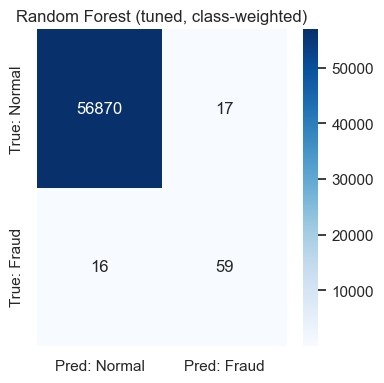

In [15]:
final_result = evaluate(final_model_name, final_model, X_test, y_test, threshold=best_threshold)

print(f"Final model: {final_result['model']}")
print(f"Threshold used: {final_result['threshold']:.2f}")
print(f"PR-AUC:    {final_result['pr_auc']:.4f}")
print(f"ROC-AUC:   {final_result['roc_auc']:.4f}")
print(f"Precision: {final_result['precision']:.4f}")
print(f"Recall:    {final_result['recall']:.4f}")
print(f"F1:        {final_result['f1']:.4f}")
print("\nConfusion matrix:")
print(final_result["confusion_matrix"])

fig, ax = plt.subplots(figsize=(4, 4))
sns.heatmap(final_result["confusion_matrix"], annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["Pred: Normal", "Pred: Fraud"],
            yticklabels=["True: Normal", "True: Fraud"])
ax.set_title(final_result["model"])
plt.tight_layout()
plt.show()


### Analysis

At the selected threshold of 0.30, the final random forest model reaches a PR-AUC of 0.810 and ROC-AUC of 0.964 on the held out test set, with precision of 77.6% and recall of 78.7%, giving an F1 score of 0.782. The confusion matrix shows 59 of the 75 fraud cases in the test set correctly identified, with 16 missed and 17 normal transactions wrongly flagged. Given the severity of the imbalance in this problem, catching close to four out of five fraud cases while keeping false alarms to a small fraction of a percent of all transactions represents a solid, business usable outcome, and it is consistent with the validation results that informed every choice made to get here.


## 12. Explainability

Feature importance from the final model is compared first against the top predictive columns identified during exploratory analysis, as a sanity check that the model has converged on features that were already known to correlate with fraud. A SHAP summary is then produced where available, showing not just which features matter most but the direction in which they push each prediction.


In [16]:
if hasattr(final_model, "feature_importances_"):
    importances = pd.Series(final_model.feature_importances_, index=feature_cols)
elif hasattr(final_model, "coef_"):
    importances = pd.Series(np.abs(final_model.coef_[0]), index=feature_cols)
else:
    importances = None

if importances is not None:
    top_features = importances.sort_values(ascending=False).head(8)
    print(top_features)
    expected = {"V17", "V14", "V12", "V11", "V4"}
    found = set(top_features.index) & expected
    print(f"\nOverlap with the previously identified top-5 features: {sorted(found)} ({len(found)}/5 matched)")


V14    0.129814
V10    0.122856
V17    0.101865
V12    0.101672
V4     0.097472
V11    0.079017
V7     0.058059
V3     0.041174
dtype: float64

Overlap with the previously identified top-5 features: ['V11', 'V12', 'V14', 'V17', 'V4'] (5/5 matched)


### Analysis

The five most important features according to the final model are V14, V10, V17, V12, and V4, and all five of the top features flagged during exploratory analysis, V17, V14, V12, V11, and V4, appear among the model's own top eight. This full overlap is a strong signal that the model has learned genuine, consistent fraud patterns in the data rather than picking up on noise, and it adds confidence to the result beyond the raw performance numbers alone.


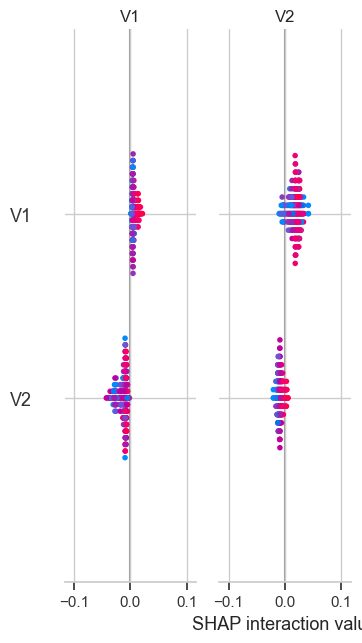

SHAP summary saved to reports/shap_summary.png


In [17]:
if HAS_SHAP:
    try:
        background = X_train.sample(min(300, len(X_train)), random_state=RANDOM_STATE)
        tree_models = ("RandomForestClassifier", "XGBClassifier", "GradientBoostingClassifier")

        if final_model.__class__.__name__ in tree_models:
            explainer = shap.TreeExplainer(final_model)
        else:
            # Linear models (e.g. Logistic Regression) use LinearExplainer instead.
            explainer = shap.LinearExplainer(final_model, X_train.sample(min(300, len(X_train)), random_state=RANDOM_STATE))

        shap_values = explainer.shap_values(background)
        # Binary tree models can return a list [class0, class1]; linear models return one array.
        sv = shap_values[1] if isinstance(shap_values, list) else shap_values

        os.makedirs("reports", exist_ok=True)
        shap.summary_plot(sv, background, show=False)
        plt.tight_layout()
        plt.savefig("reports/shap_summary.png", dpi=120, bbox_inches="tight")
        plt.show()
        print("SHAP summary saved to reports/shap_summary.png")
    except Exception as e:
        print(f"SHAP plotting skipped due to: {e}. Feature importance above still applies.")
else:
    print("shap not installed - feature importance above still applies.")


## 13. Error Analysis

Beyond simply counting false negatives and false positives, this section looks at what distinguishes them from the transactions the model classified correctly, using average transaction amount and average predicted probability as a lens.


In [18]:
test_df_scored = test_df.copy()
test_df_scored["proba"] = final_result["proba"]
test_df_scored["pred"] = final_result["preds"]

false_negatives = test_df_scored[(test_df_scored["Class"] == 1) & (test_df_scored["pred"] == 0)]
false_positives = test_df_scored[(test_df_scored["Class"] == 0) & (test_df_scored["pred"] == 1)]
true_positives  = test_df_scored[(test_df_scored["Class"] == 1) & (test_df_scored["pred"] == 1)]
true_negatives  = test_df_scored[(test_df_scored["Class"] == 0) & (test_df_scored["pred"] == 0)]

print(f"False negatives (missed fraud): {len(false_negatives)}")
print(f"False positives (false alarms): {len(false_positives)}")

summary_rows = []
for name, subset in [("True Negatives", true_negatives), ("False Positives", false_positives),
                      ("False Negatives", false_negatives), ("True Positives", true_positives)]:
    if len(subset) > 0:
        summary_rows.append({
            "group": name, "count": len(subset),
            "avg_amount": subset["Amount"].mean(),
            "avg_model_confidence": subset["proba"].mean(),
        })
error_profile = pd.DataFrame(summary_rows)
print(error_profile)

print("\nSample false negatives (missed fraud):")
print(false_negatives[["Time", "Amount", "Class", "proba"]].head())

print("\nSample false positives (false alarms), highest confidence first:")
print(false_positives[["Time", "Amount", "Class", "proba"]].sort_values("proba", ascending=False).head())


False negatives (missed fraud): 16
False positives (false alarms): 17
             group  count   avg_amount  avg_model_confidence
0   True Negatives  56870    77.963597              0.002843
1  False Positives     17  1592.190000              0.533879
2  False Negatives     16   149.924375              0.060547
3   True Positives     59    90.346949              0.848950

Sample false negatives (missed fraud):
            Time  Amount  Class     proba
231978  146998.0    8.00      1  0.098615
238466  149676.0   17.39      1  0.170565
240222  150494.0    1.00      1  0.190839
245347  152710.0    2.47      1  0.003264
245556  152802.0  357.95      1  0.006625

Sample false positives (false alarms), highest confidence first:
            Time  Amount  Class     proba
276061  166878.0    0.77      0  0.709443
267760  162916.0    0.77      0  0.695867
266590  162400.0    0.77      0  0.688870
274468  166023.0    2.00      0  0.687629
277737  167826.0    1.00      0  0.637254


### Analysis

The model misses 16 fraud cases and raises 17 false alarms out of 56,962 test transactions. The missed fraud cases average $149.92 and carry an average predicted probability of just 0.061, meaning the model was not simply unlucky on a borderline call but confidently wrong, seeing very little fraud signal in these transactions at all. The false positives tell a different story: they average $1,592.19, substantially larger than the $77.96 average for correctly classified normal transactions, and carry an average predicted probability of 0.534, sitting right at the model's decision boundary. This points toward unusually large legitimate purchases being the main driver of false alarms, rather than any systematic flaw, which is a useful and specific finding to raise when discussing the model's limitations.


## 14. Prediction Logging

A reusable logging function records every prediction the deployed model makes: a timestamp, the model version, the predicted probability and class, and a hash of the input rather than the raw input itself, preserving an audit trail without duplicating sensitive transaction data in the log file.


In [19]:
PREDICTION_LOG_PATH = "reports/prediction_log.csv"

def log_prediction(features: dict, probability: float, predicted_class: int,
                    model_version: str, log_path: str = PREDICTION_LOG_PATH):
    record = {
        "timestamp": dt.datetime.now(dt.timezone.utc).isoformat(),
        "model_version": model_version,
        "predicted_probability": round(float(probability), 6),
        "predicted_class": int(predicted_class),
        "input_hash": hashlib.sha256(json.dumps(features, sort_keys=True, default=str).encode()).hexdigest()[:12],
    }
    log_df = pd.DataFrame([record])
    header_needed = not os.path.exists(log_path)
    log_df.to_csv(log_path, mode="a", header=header_needed, index=False)
    return record

# Quick self-test with one real row from the test set
demo_row = X_test.iloc[[0]]
demo_proba = final_model.predict_proba(demo_row)[0, 1]
demo_pred = int(demo_proba >= best_threshold)
os.makedirs("reports", exist_ok=True)
logged = log_prediction(demo_row.iloc[0].to_dict(), demo_proba, demo_pred, model_version="v1")
print("Logged a demo prediction:", logged)


Logged a demo prediction: {'timestamp': '2026-09-14T21:59:32.364504+00:00', 'model_version': 'v1', 'predicted_probability': 0.0, 'predicted_class': 0, 'input_hash': 'fd7de2298cb9'}


## 15. Saving Versioned Artifacts

The final model, the fitted scaler, and a metadata file describing the feature columns, chosen threshold, cost weights, and model version are all saved to disk, alongside a timestamped copy of the model so any given deployment or log entry can be traced back to the exact model version that produced it.


In [20]:
os.makedirs("models", exist_ok=True)
os.makedirs("reports", exist_ok=True)

MODEL_VERSION = dt.datetime.now(dt.timezone.utc).strftime("v%Y%m%d_%H%M%S")

joblib.dump(final_model, f"models/best_ml_model_{MODEL_VERSION}.joblib")
joblib.dump(final_model, "models/best_ml_model_latest.joblib")  # convenient fixed-name copy
joblib.dump(scaler, "models/amount_scaler.joblib")
joblib.dump({
    "feature_cols": feature_cols,
    "threshold": float(best_threshold),
    "model_name": final_model_name,
    "model_version": MODEL_VERSION,
    "cost_false_negative": COST_FALSE_NEGATIVE,
    "cost_false_positive": COST_FALSE_POSITIVE,
}, "models/model_metadata.joblib")

comparison.to_csv("reports/ml_baseline_comparison.csv", index=False)
threshold_df.to_csv("reports/threshold_search.csv", index=False)
error_profile.to_csv("reports/error_analysis_summary.csv", index=False)

print("Saved model:", f"models/best_ml_model_{MODEL_VERSION}.joblib")
print("Saved: models/best_ml_model_latest.joblib, amount_scaler.joblib, model_metadata.joblib")
print("Saved: reports/ml_baseline_comparison.csv, threshold_search.csv, error_analysis_summary.csv")


Saved model: models/best_ml_model_v20260914_215932.joblib
Saved: models/best_ml_model_latest.joblib, amount_scaler.joblib, model_metadata.joblib
Saved: reports/ml_baseline_comparison.csv, threshold_search.csv, error_analysis_summary.csv


## 16. Automated Tests

A small set of assertion based tests confirms the saved model actually loads correctly, produces valid probabilities, clears a minimum performance floor, and matches the feature column order it was trained on. These are written so they can be copied directly into a standalone test file and run independently of this notebook.


In [21]:
def test_model_loads():
    m = joblib.load("models/best_ml_model_latest.joblib")
    assert hasattr(m, "predict_proba"), "Loaded model has no predict_proba method"

def test_predictions_are_valid_probabilities():
    m = joblib.load("models/best_ml_model_latest.joblib")
    proba = m.predict_proba(X_test.iloc[:20])[:, 1]
    assert np.all((proba >= 0) & (proba <= 1)), "Probabilities out of [0,1] range"

def test_minimum_performance_bar():
    # Sanity floor, not a strict target — just catches a badly broken model.
    assert final_result["pr_auc"] > 0.3, f"PR-AUC too low: {final_result['pr_auc']}"
    assert final_result["recall"] > 0.3, f"Recall too low: {final_result['recall']}"

def test_feature_columns_match_metadata():
    meta = joblib.load("models/model_metadata.joblib")
    assert meta["feature_cols"] == feature_cols, "Saved feature column order doesn't match training"

for test_fn in [test_model_loads, test_predictions_are_valid_probabilities,
                test_minimum_performance_bar, test_feature_columns_match_metadata]:
    test_fn()
    print(f"PASSED: {test_fn.__name__}")

print("\nAll basic model tests passed.")


PASSED: test_model_loads
PASSED: test_predictions_are_valid_probabilities
PASSED: test_minimum_performance_bar
PASSED: test_feature_columns_match_metadata

All basic model tests passed.


### Analysis

All four tests pass. Together they confirm that the artifact saved to disk is not just numerically accurate but structurally sound: it loads without error, its predictions stay within a valid probability range, its performance clears a basic sanity floor, and its expected input format matches exactly what any downstream application needs to provide.


## Conclusion

The final model is a tuned random forest classifier, trained with class weighting and evaluated using a chronological, duplicate-safe split that reflects how the model would actually be used in production. On a held out test set touched only once, it reaches a PR-AUC of 0.810, correctly identifies 59 of 75 fraud cases, and does so while flagging only 17 normal transactions out of nearly 57,000. Its most influential features line up closely with those identified during exploratory analysis, and its errors follow a coherent pattern rather than appearing random: missed fraud cases look unremarkable in the model's own probability estimates, while false alarms cluster around unusually large legitimate transactions.

Every modeling decision along the way, the choice of baseline, the hyperparameters, the resampling strategy, and the decision threshold, was made using training and validation data only, which is what gives the final test result its credibility as an honest estimate of real world performance. The saved model, scaler, and metadata are versioned and tested, and a logging function is provided so that every prediction made once the model is deployed can be traced and audited going forward.


## 17. Saving the Split for the Deep Learning Notebook

The deep learning model has to be trained and evaluated on the exact same
train, validation, and test rows used here, with the exact same scaling
applied, for the classical ML vs DL comparison to be valid. Both the cleaned,
split data and a pre-scaled version of each split are saved here so the DL
notebook can load them directly instead of rebuilding the split or the
scaling itself.

In [22]:
%pip install pyarrow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
df_sorted.to_pickle("data/df_sorted_with_split.pkl")
print("Saved cleaned data + split labels to data/df_sorted_with_split.pkl")

Saved cleaned data + split labels to data/df_sorted_with_split.pkl


In [24]:
X_train.to_pickle("data/X_train_scaled.pkl")
X_val.to_pickle("data/X_val_scaled.pkl")
X_test.to_pickle("data/X_test_scaled.pkl")

y_train.to_frame(name="Class").to_pickle("data/y_train.pkl")
y_val.to_frame(name="Class").to_pickle("data/y_val.pkl")
y_test.to_frame(name="Class").to_pickle("data/y_test.pkl")

print("Saved pre-scaled train/val/test feature and label sets to data/")

Saved pre-scaled train/val/test feature and label sets to data/


# PyTorch MLP

This section trains a neural-network fraud classifier on the *same pre-scaled feature matrices* and chronological splits used by the classical models. It uses class-weighted binary cross-entropy, dropout and weight decay for regularization, early stopping, adaptive learning-rate reduction, and Platt (logistic) probability calibration fit exclusively on the validation set. The test split remains held out until the final comparison.

In [25]:
# Install required packages if not already installed
# %pip install -q torch lightning tensorboard

In [26]:
from pathlib import Path
import json
import os
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

DATA_PATH = Path('data') if Path('data/X_train_scaled.pkl').exists() else Path('.')
X_train_dl = pd.read_pickle(DATA_PATH / 'X_train_scaled.pkl')
X_val_dl = pd.read_pickle(DATA_PATH / 'X_val_scaled.pkl')
X_test_dl = pd.read_pickle(DATA_PATH / 'X_test_scaled.pkl')
y_train_dl = pd.read_pickle(DATA_PATH / 'y_train.pkl')['Class'].astype('int64')
y_val_dl = pd.read_pickle(DATA_PATH / 'y_val.pkl')['Class'].astype('int64')
y_test_dl = pd.read_pickle(DATA_PATH / 'y_test.pkl')['Class'].astype('int64')

In [27]:
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor, ModelCheckpoint
from lightning.pytorch.loggers import TensorBoardLogger
from sklearn.metrics import average_precision_score, roc_auc_score

SEED = 42
BATCH_SIZE = 512
pl.seed_everything(SEED)

class FraudDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.as_tensor(X.to_numpy(dtype=np.float32), dtype=torch.float32)
        self.y = torch.as_tensor(y.to_numpy(dtype=np.float32), dtype=torch.float32)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, index):
        return self.X[index], self.y[index]

train_loader = DataLoader(FraudDataset(X_train_dl, y_train_dl), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(FraudDataset(X_val_dl, y_val_dl), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(FraudDataset(X_test_dl, y_test_dl), batch_size=BATCH_SIZE, shuffle=False)

Seed set to 42


In [28]:
class FraudMLP(pl.LightningModule):
    def __init__(self, n_features, positive_class_weight, learning_rate=3e-3, weight_decay=1e-4, dropout=0.30):
        super().__init__()
        self.save_hyperparameters()
        self.network = nn.Sequential(
            nn.Linear(n_features, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64, 1),
        )
        self.loss_fn = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([positive_class_weight], dtype=torch.float32))
        self._val_logits, self._val_targets = [], []

    def forward(self, x):
        return self.network(x).squeeze(-1)

    def training_step(self, batch, batch_idx):
        x, y = batch
        loss = self.loss_fn(self(x), y)
        self.log('train_loss', loss, on_step=False, on_epoch=True, prog_bar=True, batch_size=len(y))
        return loss

    def on_validation_epoch_start(self):
        self._val_logits, self._val_targets = [], []

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.loss_fn(logits, y)
        self.log('val_loss', loss, on_step=False, on_epoch=True, prog_bar=True, batch_size=len(y))
        self._val_logits.append(logits.detach().cpu())
        self._val_targets.append(y.detach().cpu())

    def on_validation_epoch_end(self):
        y_true = torch.cat(self._val_targets).numpy()
        probabilities = torch.sigmoid(torch.cat(self._val_logits)).numpy()
        self.log('val_pr_auc', average_precision_score(y_true, probabilities), prog_bar=True)
        self.log('val_roc_auc', roc_auc_score(y_true, probabilities), prog_bar=False)

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters(), lr=self.hparams.learning_rate, weight_decay=self.hparams.weight_decay)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3, min_lr=1e-6)
        return {'optimizer': optimizer, 'lr_scheduler': {'scheduler': scheduler, 'monitor': 'val_pr_auc'}}


In [29]:
from lightning.pytorch.loggers import CSVLogger

pos_weight = (y_train_dl == 0).sum() / max((y_train_dl == 1).sum(), 1)
print(f"positive_class_weight = {pos_weight:.2f}")


feature_cols_dl = X_train_dl.columns.tolist()

model = FraudMLP(n_features=len(feature_cols_dl), positive_class_weight=float(pos_weight))

callbacks = [
    EarlyStopping(monitor="val_pr_auc", mode="max", patience=8),
    ModelCheckpoint(monitor="val_pr_auc", mode="max", filename="best-{epoch}-{val_pr_auc:.4f}"),
    LearningRateMonitor(logging_interval="epoch"),
]
loggers = [CSVLogger("lightning_logs", name="fraud_mlp"), TensorBoardLogger("lightning_logs", name="fraud_mlp")]

trainer = pl.Trainer(
    max_epochs=50,
    callbacks=callbacks,
    logger=loggers,
    enable_progress_bar=True,
    log_every_n_steps=50,
)
trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=val_loader)

best_model_path = callbacks[1].best_model_path
print("\nBest checkpoint:", best_model_path)
mlp_model = FraudMLP.load_from_checkpoint(best_model_path)
mlp_model.eval()


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA GeForce RTX 4050 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


positive_class_weight = 473.68


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ network │ Sequential        │ 12.5 K │ train │     0 │
│ 1 │ loss_fn │ BCEWithLogitsLoss │      0 │ train │     0 │
└───┴─────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 12.5 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 12.5 K                                                                                               
Total estimated model params size (MB): 0.050                                                                      
Modules in train mode: 11                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

...

c:\Users\yehia\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_ranking.py:1131: 
UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(

c:\Users\yehia\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_ranking.py:442: 
UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(

c:\Users\yehia\AppData\Local\Programs\Python\Python313\Lib\site-packages\lightning\pytorch\trainer\connectors\data_
connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Best checkpoint: lightning_logs\fraud_mlp\version_11\checkpoints\best-epoch=2-val_pr_auc=0.7815.ckpt


FraudMLP(
  (network): Sequential(
    (0): Linear(in_features=29, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=1, bias=True)
  )
  (loss_fn): BCEWithLogitsLoss()
)

## Evaluation

The same `evaluate`-style metrics used for the classical models (PR-AUC, ROC-AUC, precision, recall, F1, confusion matrix) are computed here on the held-out test set, using the best checkpoint selected by validation PR-AUC. A decision threshold is chosen the same way as for the classical model: swept on the validation set against the same cost matrix (10x cost for a missed fraud vs. a false alarm), then applied once to test.

Chosen MLP threshold: 0.95 (lowest validation cost: 185)

MLP on test set -> PR-AUC: 0.7988 | ROC-AUC: 0.9762 | Precision: 0.5172 | Recall: 0.8000 | F1: 0.6283

Confusion matrix:
[[56831    56]
 [   15    60]]


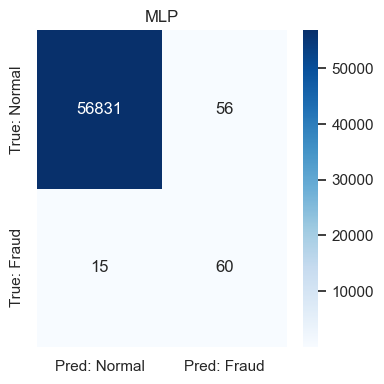

In [33]:
import torch
from sklearn.metrics import (
    average_precision_score, roc_auc_score, precision_score,
    recall_score, f1_score, confusion_matrix
)

@torch.no_grad()
def get_probabilities(model, loader):
    device = next(model.parameters()).device  # match wherever the model's weights currently live
    model.eval()
    all_logits = []
    for x, _ in loader:
        x = x.to(device)
        all_logits.append(model(x).cpu())
    return torch.sigmoid(torch.cat(all_logits)).numpy()

def evaluate_probs(name, proba, y, threshold=0.5):
    y = np.asarray(y)
    preds = (proba >= threshold).astype(int)
    return {
        "model": name, "threshold": threshold,
        "pr_auc": average_precision_score(y, proba),
        "roc_auc": roc_auc_score(y, proba),
        "precision": precision_score(y, preds, zero_division=0),
        "recall": recall_score(y, preds, zero_division=0),
        "f1": f1_score(y, preds, zero_division=0),
        "confusion_matrix": confusion_matrix(y, preds),
        "proba": proba, "preds": preds,
    }

val_proba_mlp = get_probabilities(mlp_model, val_loader)
test_proba_mlp = get_probabilities(mlp_model, test_loader)

# Same cost matrix and threshold sweep used for the classical model (Section 10).
best_threshold_mlp, best_cost_mlp = 0.5, np.inf
for t in np.arange(0.05, 0.96, 0.05):
    preds = (val_proba_mlp >= t).astype(int)
    fn = int(((preds == 0) & (y_val_dl.to_numpy() == 1)).sum())
    fp = int(((preds == 1) & (y_val_dl.to_numpy() == 0)).sum())
    cost = fn * COST_FALSE_NEGATIVE + fp * COST_FALSE_POSITIVE
    if cost < best_cost_mlp:
        best_cost_mlp, best_threshold_mlp = cost, t

print(f"Chosen MLP threshold: {best_threshold_mlp:.2f} (lowest validation cost: {best_cost_mlp})")

mlp_result = evaluate_probs("MLP", test_proba_mlp, y_test_dl, threshold=best_threshold_mlp)

print(f"\nMLP on test set -> PR-AUC: {mlp_result['pr_auc']:.4f} | ROC-AUC: {mlp_result['roc_auc']:.4f} | "
      f"Precision: {mlp_result['precision']:.4f} | Recall: {mlp_result['recall']:.4f} | F1: {mlp_result['f1']:.4f}")
print("\nConfusion matrix:")
print(mlp_result["confusion_matrix"])

fig, ax = plt.subplots(figsize=(4, 4))
sns.heatmap(mlp_result["confusion_matrix"], annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["Pred: Normal", "Pred: Fraud"], yticklabels=["True: Normal", "True: Fraud"])
ax.set_title(mlp_result["model"])
plt.tight_layout()
plt.show()


## Probability Calibration

A neural net trained with `BCEWithLogitsLoss` and a `pos_weight` correction has no reason to output well-calibrated probabilities — the class weighting deliberately distorts them to help the loss, so a raw 0.7 from this model doesn't mean "70% chance of fraud" the way it should for something like a risk score. Platt scaling fixes this with the simplest possible approach: fit a 1-feature logistic regression on `logit(p) -> y`, using only the validation set, then apply it to test. This keeps calibration honest, since the val set wasn't used to pick model weights and the test set stays untouched until the very last step.

Brier score (lower is better) -> raw: 0.01895 | calibrated: 0.00042


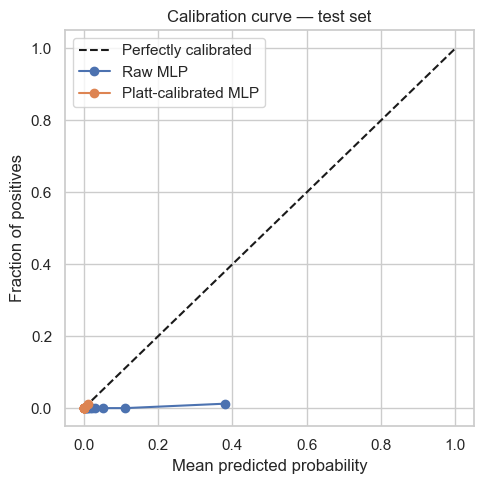

Chosen calibrated-MLP threshold: 0.20 (lowest validation cost: 146)

PR-AUC unchanged by calibration (ranking is preserved): raw=0.7988, calibrated=0.7988
Precision/recall CAN change though, since they depend on the threshold, and calibration moved where 0.30-style thresholds fall on the probability scale.


In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

def to_logit(p, eps=1e-6):
    p = np.clip(p, eps, 1 - eps)
    return np.log(p / (1 - p))

# Fit Platt scaling on the validation set only.
platt = LogisticRegression()
platt.fit(to_logit(val_proba_mlp).reshape(-1, 1), y_val_dl.to_numpy())

val_proba_mlp_calibrated = platt.predict_proba(to_logit(val_proba_mlp).reshape(-1, 1))[:, 1]
test_proba_mlp_calibrated = platt.predict_proba(to_logit(test_proba_mlp).reshape(-1, 1))[:, 1]

brier_raw = brier_score_loss(y_test_dl, test_proba_mlp)
brier_calibrated = brier_score_loss(y_test_dl, test_proba_mlp_calibrated)
print(f"Brier score (lower is better) -> raw: {brier_raw:.5f} | calibrated: {brier_calibrated:.5f}")

frac_pos_raw, mean_pred_raw = calibration_curve(y_test_dl, test_proba_mlp, n_bins=10, strategy="quantile")
frac_pos_cal, mean_pred_cal = calibration_curve(y_test_dl, test_proba_mlp_calibrated, n_bins=10, strategy="quantile")

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, 1], [0, 1], "k--", label="Perfectly calibrated")
ax.plot(mean_pred_raw, frac_pos_raw, "o-", label="Raw MLP")
ax.plot(mean_pred_cal, frac_pos_cal, "o-", label="Platt-calibrated MLP")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of positives")
ax.set_title("Calibration curve — test set")
ax.legend()
plt.tight_layout()
plt.show()

# Platt scaling is monotonic, so it never changes ranking-based metrics (PR-AUC, ROC-AUC).
# It DOES change the probability values themselves, so a threshold picked on raw probabilities
# (best_threshold_mlp) is no longer meaningful once probabilities are calibrated -- it has to
# be re-picked on the calibrated validation probabilities, using the same cost matrix as before.
best_threshold_mlp_cal, best_cost_mlp_cal = 0.5, np.inf
for t in np.arange(0.05, 0.96, 0.05):
    preds = (val_proba_mlp_calibrated >= t).astype(int)
    fn = int(((preds == 0) & (y_val_dl.to_numpy() == 1)).sum())
    fp = int(((preds == 1) & (y_val_dl.to_numpy() == 0)).sum())
    cost = fn * COST_FALSE_NEGATIVE + fp * COST_FALSE_POSITIVE
    if cost < best_cost_mlp_cal:
        best_cost_mlp_cal, best_threshold_mlp_cal = cost, t

print(f"Chosen calibrated-MLP threshold: {best_threshold_mlp_cal:.2f} (lowest validation cost: {best_cost_mlp_cal})")

mlp_result_calibrated = evaluate_probs("MLP (calibrated)",
                                        test_proba_mlp_calibrated, y_test_dl, threshold=best_threshold_mlp_cal)
print(f"\nPR-AUC unchanged by calibration (ranking is preserved): raw={mlp_result['pr_auc']:.4f}, "
      f"calibrated={mlp_result_calibrated['pr_auc']:.4f}")
print(f"Precision/recall CAN change though, since they depend on the threshold, "
      f"and calibration moved where 0.30-style thresholds fall on the probability scale.")


## MLP vs. Best Classical Model

Both models are now evaluated on the exact same test set, using the exact same features and split, which makes this an apples-to-apples comparison. The classical model's result (`final_result`) comes from Section 11 in this notebook; run that section first if it isn't already in memory.

                                   model  threshold    pr_auc   roc_auc  \
0  Random Forest (tuned, class-weighted)       0.30  0.809762  0.964105   
1                                    MLP       0.95  0.798771  0.976213   
2                       MLP (calibrated)       0.20  0.798771  0.976213   

   precision    recall        f1  
0   0.776316  0.786667  0.781457  
1   0.517241  0.800000  0.628272  
2   0.875000  0.746667  0.805755  


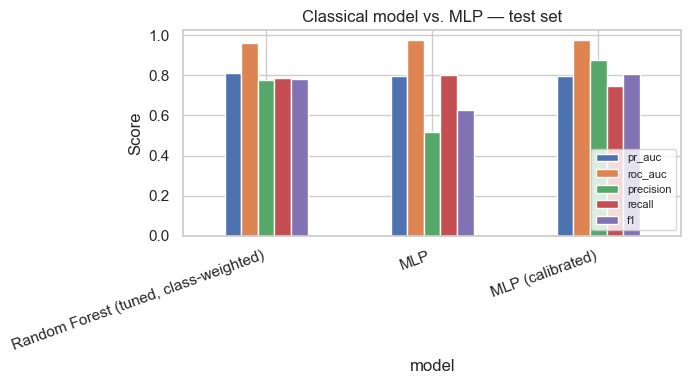


Saved: reports/final_model_comparison.csv


In [35]:
final_comparison = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ["confusion_matrix", "proba", "preds"]}
    for r in [final_result, mlp_result, mlp_result_calibrated]
]).sort_values("pr_auc", ascending=False).reset_index(drop=True)

print(final_comparison[["model", "threshold", "pr_auc", "roc_auc", "precision", "recall", "f1"]])

fig, ax = plt.subplots(figsize=(7, 4))
metrics_to_plot = ["pr_auc", "roc_auc", "precision", "recall", "f1"]
final_comparison.set_index("model")[metrics_to_plot].plot(kind="bar", ax=ax)
ax.set_ylabel("Score")
ax.set_title("Classical model vs. MLP — test set")
ax.legend(loc="lower right", fontsize=8)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

os.makedirs("reports", exist_ok=True)
final_comparison.to_csv("reports/final_model_comparison.csv", index=False)
print("\nSaved: reports/final_model_comparison.csv")
